# 6. Validación de Variables para Predicción del Target

Este notebook realiza un análisis exhaustivo de las variables pre-operatorias **ya codificadas** para identificar las más significativas en la predicción de la variable objetivo.

## Estrategia:
Dado que todas las variables están codificadas (one-hot, label encoding, binarias), se aplican **métodos estadísticos específicos** según el tipo de variable:

- **Binarias**: Phi coefficient, Chi-cuadrado 2×2
- **Ordinales**: Correlación de Spearman (no asume linealidad)
- **Nominales/Multilabel (One-Hot)**: Cramér's V agrupado por feature original
- **Continuas**: Correlación Point-Biserial, pruebas de diferencia de medias
- **Todas**: Mutual Information, Random Forest Feature Importance

## 1. Importación de Librerías

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, spearmanr, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from collections import defaultdict
import re

warnings.filterwarnings('ignore')

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de tamaño de figuras
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## 2. Carga de Datos

In [38]:
import xml.dom.NodeFilter
# Cargar dataset completo
df = pd.read_excel('../data/OPERA_COMPLETO.xlsx')

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nDistribución del target:")
print(df['target'].value_counts())
print(f"\nPorcentaje de clases:")
print(df['target'].value_counts(normalize=True).mul(100).round(2))

print(f"\nPrimeras 10 columnas:")
print(df.columns[:10].tolist())

Dataset cargado: 29,865 filas × 237 columnas

Distribución del target:
target
1    17475
0    12390
Name: count, dtype: int64

Porcentaje de clases:
target
1    58.51
0    41.49
Name: proportion, dtype: float64

Primeras 10 columnas:
['Documento PMD', 'Edad', 'Peso (Kg)', 'Talla (cm)', 'IMC', 'Antecedentes anestésicos', 'Tensión Arterial Sistólica (mm/Hg)', 'Tensión Arterial Diastólica (mm/Hg)', 'Tensión Arterial Media (mm/Hg)', 'Frecuencia Respiratoria']


## 3. Definición de Tipos de Variables

Basado en la documentación de variables y los nombres reales en el dataset.

In [39]:
# Columnas a excluir del análisis (IDs)
id_columns = ['Documento PMD']

# Variables CONTINUAS (numéricas verdaderas)
# Nota: Los nombres tienen problemas de encoding (Ã© = é, Ã³ = ó)
continuous_vars = [
    'Edad', 'Peso (Kg)', 'Talla (cm)', 'IMC',
    'Hora_decimal',
    # Exámenes de laboratorio (continuas)
    'Examen_Hemoglobina(g/dl)', 'Examen_PT (INR)', 'Examen_Glicemia (mg/dl)',
    'Examen_Hematocrito (%)', 'Examen_Plaquetas (ml)', 'Examen_Leucocitos (ml)',
    'Examen_PTT', 'Examen_K (meq/L)', 'Examen_Na (meq/L)', 'Examen_P de O',
    # Scores predichos
    'score_dx_critical', 'score_dx_high_severity', 'score_dx_low_severity', 'score_dx_medium_severity', 'score_dx_moderate_severity', 
    'score_proc_critical', 'score_proc_high_severity', 'score_proc_low_severity', 'score_proc_medium_severity', 'score_proc_moderate_severity',
    'score_proc_ant_critical', 'score_proc_ant_high_severity', 'score_proc_ant_low_severity', 'score_proc_ant_medium_severity', 'score_proc_ant_moderate_severity'
]

# Buscar nombres con encoding issues
for base_name in ['Antecedentes anest', 'Tensi', 'Frecuencia Respiratoria', 'Temperatura']:
    matches = [col for col in df.columns if base_name in col and col not in continuous_vars]
    continuous_vars.extend(matches)

# Variables BINARIAS (0/1 sin orden) - con _encoded
binary_vars = [
    'Sexo_encoded', 
    'Arritmia_encoded',
    'Disnea_encoded', 
    'Angina_encoded'
]

# Variables ORDINALES (tienen orden lógico) - con _encoded
ordinal_vars = [
    'Puntaje Mallampati',
    'anio', 'mes', 'dia_semana',
    'predicted_label_dx_encoded', 'predicted_label_proc_encoded', 'predicted_label_proc_ant_encoded', 
]

# Buscar ordinales con encoding issues
for base_name in ['Atenci', 'Estado Nutricional', 'Apertura Visual', 'Respuesta Verbal', 
                  'Respuesta Motora', 'Cuello M', 'Apertura Oral']:
    matches = [col for col in df.columns if base_name in col and '_encoded' in col]
    ordinal_vars.extend(matches)

# Variables NOMINALES con ONE-HOT ENCODING
# Usar patrones que manejen problemas de encoding
onehot_patterns = {
    'Grupo Sanguíneo': r'^Grupo Sangu',
    'RH': r'^RH_',
    'Condición': r'^Condici',
    'PrÃ³tesis Dental': r'^PrÃ³tesis Dental',
    'Alérgeno': r'^AlÃ©rgeno',
    'Anestesia previa': r'^Anestesia previa_',
    'Antecedente neurológicos': r'^Antecedente neurol',
    'Antecedente respiratorios': r'^Antecedente respiratorios_',
    'Antecedentes cardiovasculares': r'^Antecedentes cardiovasculares_',
    'Antecedente hematológicos': r'^Antecedente hematol',
    'Antecedente endocrinológicos': r'^Antecedente endocrinol',
    'Antecedente renales': r'^Antecedente renales_',
    'Antecedente gastrointestinales': r'^Antecedente gastrointestinales_',
    'Sistema Nervioso': r'^Sistema Nervioso_',
    'Sistema Respiratorio': r'^Sistema Respiratorio_',
    'Sistema cardiovascular': r'^Sistema cardiovascular_',
    'Abdomen': r'^Abdomen_',
    'Color de Piel': r'^Color de Piel_',
    'Tipo de anestesia propuesta': r'^Tipo de anestesia propuesta_',
    'Dx Preoperatorio Code': r'^Dx Preoperatorio Code_',
    'Procedimiento propuesto Code': r'^Procedimiento propuesto Code_',
    'Antecedentes quirúrgicos Code': r'^Antecedentes quir.*rgicos Code_'
}

# Identificar columnas disponibles en el dataset
available_columns = [col for col in df.columns if col not in id_columns + ['target']]

# Agrupar variables one-hot
onehot_groups = defaultdict(list)
for feature_name, pattern in onehot_patterns.items():
    matching_cols = [col for col in available_columns if re.search(pattern, col)]
    if matching_cols:
        onehot_groups[feature_name] = matching_cols

# Identificar todas las columnas one-hot
all_onehot_cols = [col for cols in onehot_groups.values() for col in cols]

# Filtrar variables que existen en el dataset
continuous_vars = list(set([v for v in continuous_vars if v in available_columns]))
binary_vars = [v for v in binary_vars if v in available_columns]
ordinal_vars = list(set([v for v in ordinal_vars if v in available_columns]))

# Variables no clasificadas
classified_vars = set(continuous_vars + binary_vars + ordinal_vars + all_onehot_cols)
unclassified_vars = [col for col in available_columns if col not in classified_vars]

print("=" * 80)
print("CLASIFICACIÓN DE VARIABLES")
print("=" * 80)
print(f"\nContinuas: {len(continuous_vars)}")
print(f"Binarias: {len(binary_vars)}")
print(f"Ordinales: {len(ordinal_vars)}")
print(f"Grupos One-Hot: {len(onehot_groups)} ({len(all_onehot_cols)} columnas)")
print(f"No clasificadas: {len(unclassified_vars)}")
print(f"\nTotal features a analizar: {len(available_columns)}")

CLASIFICACIÓN DE VARIABLES

Continuas: 36
Binarias: 4
Ordinales: 14
Grupos One-Hot: 20 (163 columnas)
No clasificadas: 18

Total features a analizar: 235


In [40]:
# Mostrar grupos one-hot identificados
print("\nGRUPOS ONE-HOT IDENTIFICADOS:")
print("=" * 80)
for feature_name, cols in sorted(onehot_groups.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"\n{feature_name}: {len(cols)} columnas")
    if len(cols) <= 5:
        print(f"  Columnas: {cols}")
    else:
        print(f"  Primeras 5: {cols[:5]}")

print(f"\n\nVariables continuas identificadas ({len(continuous_vars)}):")
for v in sorted(continuous_vars):
    print(f"  - {v}")

print(f"\n\nVariables binarias identificadas ({len(binary_vars)}):")
for v in sorted(binary_vars):
    print(f"  - {v}")

print(f"\n\nVariables ordinales identificadas ({len(ordinal_vars)}):")
for v in sorted(ordinal_vars):
    print(f"  - {v}")


GRUPOS ONE-HOT IDENTIFICADOS:

Dx Preoperatorio Code: 27 columnas
  Primeras 5: ['Dx Preoperatorio Code_A', 'Dx Preoperatorio Code_B', 'Dx Preoperatorio Code_C', 'Dx Preoperatorio Code_D', 'Dx Preoperatorio Code_E']

Procedimiento propuesto Code: 17 columnas
  Primeras 5: ['Procedimiento propuesto Code_A', 'Procedimiento propuesto Code_B', 'Procedimiento propuesto Code_C', 'Procedimiento propuesto Code_E', 'Procedimiento propuesto Code_G']

Antecedentes quirúrgicos Code: 17 columnas
  Primeras 5: ['Antecedentes quirúrgicos Code_A', 'Antecedentes quirúrgicos Code_B', 'Antecedentes quirúrgicos Code_C', 'Antecedentes quirúrgicos Code_E', 'Antecedentes quirúrgicos Code_G']

Anestesia previa: 16 columnas
  Primeras 5: ['Anestesia previa_bag', 'Anestesia previa_bloqueo', 'Anestesia previa_conductiva', 'Anestesia previa_desconocido', 'Anestesia previa_epidural']

Condición: 9 columnas
  Primeras 5: ['Condición_alcohol', 'Condición_embarazo actual', 'Condición_farmacodependencia', 'Condición_

## 4. Análisis de Variables Continuas

In [41]:
# Correlación Point-Biserial para variables continuas
continuous_results = []

for var in continuous_vars:
    valid_data = df[[var, 'target']].dropna()
    
    if len(valid_data) > 30:
        try:
            # Point-Biserial correlation
            corr, p_value = pointbiserialr(valid_data['target'], valid_data[var])
            
            # Mann-Whitney U test (no asume normalidad)
            group0 = valid_data[valid_data['target'] == 0][var]
            group1 = valid_data[valid_data['target'] == 1][var]
            u_stat, u_pvalue = mannwhitneyu(group0, group1, alternative='two-sided')
            
            # Diferencia de medias
            mean_diff = group1.mean() - group0.mean()
            
            continuous_results.append({
                'Variable': var,
                'Correlation': corr,
                'Abs_Correlation': abs(corr),
                'Corr_PValue': p_value,
                'MannWhitney_U': u_stat,
                'MW_PValue': u_pvalue,
                'Mean_Diff': mean_diff,
                'Mean_Target0': group0.mean(),
                'Mean_Target1': group1.mean(),
                'Significant': 'Sí' if p_value < 0.05 else 'No',
                'N_Valid': len(valid_data)
            })
        except Exception as e:
            print(f"Error en {var}: {e}")

continuous_df = pd.DataFrame(continuous_results).sort_values('Abs_Correlation', ascending=False)

print("=" * 80)
print("VARIABLES CONTINUAS - CORRELACIÓN CON TARGET")
print("=" * 80)
print(continuous_df.to_string(index=False))

VARIABLES CONTINUAS - CORRELACIÓN CON TARGET
                           Variable  Correlation  Abs_Correlation  Corr_PValue  MannWhitney_U    MW_PValue  Mean_Diff  Mean_Target0  Mean_Target1 Significant  N_Valid
           Examen_Hemoglobina(g/dl)     0.079187         0.079187 9.395598e-43     99604129.5 1.664180e-47   1.102589      3.569446      4.672034          Sí    29865
                                IMC     0.063135         0.063135 9.140561e-28     99932215.5 8.189837e-30   0.589013     23.976913     24.565927          Sí    29865
                score_proc_critical    -0.046612         0.046612 7.675461e-16    114365946.5 8.701880e-17  -0.012792      0.287697      0.274904          Sí    29865
                               Edad     0.044692         0.044692 1.100969e-14    102921632.0 3.602657e-13   1.907093     36.830423     38.737516          Sí    29865
           score_proc_high_severity     0.042296         0.042296 2.624810e-13    103976271.0 5.462677e-09   0.017212   

## 5. Análisis de Variables Binarias

In [42]:
# Phi coefficient para variables binarias
binary_results = []

for var in binary_vars:
    contingency_table = pd.crosstab(df[var], df['target'])
    
    if contingency_table.shape == (2, 2):
        try:
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            
            # Phi coefficient
            n = contingency_table.sum().sum()
            phi = np.sqrt(chi2 / n)
            
            # Calcular proporciones
            prop_table = pd.crosstab(df[var], df['target'], normalize='columns') * 100
            
            binary_results.append({
                'Variable': var,
                'Phi_Coefficient': phi,
                'Chi2_Statistic': chi2,
                'P_Value': p_value,
                'Significant': 'Sí' if p_value < 0.05 else 'No',
                'Prop_1_Target0': prop_table.loc[1, 0] if 1 in prop_table.index else 0,
                'Prop_1_Target1': prop_table.loc[1, 1] if 1 in prop_table.index else 0,
                'N': n
            })
        except Exception as e:
            print(f"Error en {var}: {e}")

binary_df = pd.DataFrame(binary_results).sort_values('Phi_Coefficient', ascending=False)

print("=" * 80)
print("VARIABLES BINARIAS - ASOCIACIÓN CON TARGET (PHI COEFFICIENT)")
print("=" * 80)
print(binary_df.to_string(index=False))

VARIABLES BINARIAS - ASOCIACIÓN CON TARGET (PHI COEFFICIENT)
        Variable  Phi_Coefficient  Chi2_Statistic  P_Value Significant  Prop_1_Target0  Prop_1_Target1     N
    Sexo_encoded         0.013262        5.252573 0.021914          Sí       58.942696       57.608011 29865
Arritmia_encoded         0.005552        0.920717 0.337287          No        0.121065        0.171674 29865
  Disnea_encoded         0.002410        0.173392 0.677115          No        0.024213        0.040057 29865
  Angina_encoded         0.000000        0.000000 1.000000          No        0.008071        0.005722 29865


## 6. Análisis de Variables Ordinales

In [43]:
# Correlación de Spearman para variables ordinales
ordinal_results = []

for var in ordinal_vars:
    valid_data = df[[var, 'target']].dropna()
    
    if len(valid_data) > 30:
        try:
            # Spearman correlation
            corr, p_value = spearmanr(valid_data[var], valid_data['target'])
            
            n_categories = valid_data[var].nunique()
            
            ordinal_results.append({
                'Variable': var,
                'Spearman_Corr': corr,
                'Abs_Correlation': abs(corr),
                'P_Value': p_value,
                'Significant': 'Sí' if p_value < 0.05 else 'No',
                'N_Categories': n_categories,
                'N_Valid': len(valid_data)
            })
        except Exception as e:
            print(f"Error en {var}: {e}")

ordinal_df = pd.DataFrame(ordinal_results).sort_values('Abs_Correlation', ascending=False)

print("=" * 80)
print("VARIABLES ORDINALES - CORRELACIÓN DE SPEARMAN CON TARGET")
print("=" * 80)
print(ordinal_df.to_string(index=False))

VARIABLES ORDINALES - CORRELACIÓN DE SPEARMAN CON TARGET
                        Variable  Spearman_Corr  Abs_Correlation      P_Value Significant  N_Categories  N_Valid
                            anio      -0.047029         0.047029 4.242525e-16          Sí             7    29865
    predicted_label_proc_encoded      -0.036424         0.036424 3.044624e-10          Sí             6    29865
              Puntaje Mallampati       0.032968         0.032968 1.207735e-08          Sí             4    29865
      Estado Nutricional_encoded       0.031739         0.031739 4.108491e-08          Sí             3    29865
                             mes       0.010601         0.010601 6.694174e-02          No            12    29865
      predicted_label_dx_encoded       0.009797         0.009797 9.044207e-02          No             6    29865
                      dia_semana       0.009692         0.009692 9.396379e-02          No             7    29865
                Atención_encoded       

## 7. Análisis de Variables One-Hot (Agrupadas)

In [44]:
# Análisis de grupos one-hot usando Cramér's V
onehot_results = []

for feature_name, cols in onehot_groups.items():
    try:
        # Reconstruir variable categórica original
        categorical_var = df[cols].idxmax(axis=1)
        
        # Crear tabla de contingencia
        contingency_table = pd.crosstab(categorical_var, df['target'])
        
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            
            # Cramér's V
            n = contingency_table.sum().sum()
            min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
            cramers_v = np.sqrt(chi2 / (n * min_dim))
            
            onehot_results.append({
                'Feature_Group': feature_name,
                'N_Categories': len(cols),
                'Cramers_V': cramers_v,
                'Chi2_Statistic': chi2,
                'P_Value': p_value,
                'Significant': 'Sí' if p_value < 0.05 else 'No',
                'N': n
            })
    except Exception as e:
        print(f"Error en {feature_name}: {e}")

onehot_df = pd.DataFrame(onehot_results).sort_values('Cramers_V', ascending=False)

print("=" * 80)
print("VARIABLES ONE-HOT (AGRUPADAS) - CRAMÉR'S V CON TARGET")
print("=" * 80)
print(onehot_df.to_string(index=False))

VARIABLES ONE-HOT (AGRUPADAS) - CRAMÉR'S V CON TARGET
                 Feature_Group  N_Categories  Cramers_V  Chi2_Statistic       P_Value Significant     N
   Tipo de anestesia propuesta             8   0.203856     1241.109954 9.089136e-264          Sí 29865
         Dx Preoperatorio Code            27   0.126706      479.468463  6.072562e-85          Sí 29865
  Procedimiento propuesto Code            17   0.083108      206.274105  4.264046e-35          Sí 29865
               Grupo Sanguíneo             5   0.047243       66.655136  1.152561e-13          Sí 29865
                            RH             3   0.045680       62.317916  2.936544e-14          Sí 29865
  Antecedente endocrinológicos             4   0.044268       58.525692  1.213836e-12          Sí 29865
 Antecedentes cardiovasculares             8   0.036071       38.858184  2.080064e-06          Sí 29865
              Anestesia previa            16   0.034444       35.430547  1.268965e-03          Sí 29865
          

## 9. Información Mutua (Todas las Variables)

In [45]:
# Preparar datos para Mutual Information
X = df[available_columns].copy()
y = df['target']

# Rellenar valores nulos con -1 (indicador de faltante)
X_filled = X.fillna(-1)

# Calcular Mutual Information
print("Calculando Mutual Information...")
mi_scores = mutual_info_classif(X_filled, y, random_state=42, n_neighbors=5)

mi_df = pd.DataFrame({
    'Variable': X.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\n" + "=" * 80)
print("INFORMACIÓN MUTUA - TODAS LAS VARIABLES")
print("=" * 80)
print(f"\nTop 50 variables:")
print(mi_df.head(50).to_string(index=False))

Calculando Mutual Information...

INFORMACIÓN MUTUA - TODAS LAS VARIABLES

Top 50 variables:
                                     Variable  MI_Score
                 score_proc_moderate_severity  0.049572
                          score_proc_critical  0.049467
                     score_proc_high_severity  0.049101
                      score_proc_low_severity  0.046688
                   score_proc_medium_severity  0.046677
                       score_dx_high_severity  0.037494
                        score_dx_low_severity  0.031483
                   score_dx_moderate_severity  0.030705
                            score_dx_critical  0.028872
                     score_dx_medium_severity  0.028142
         Tipo de anestesia propuesta_sedacion  0.020482
                                    Peso (Kg)  0.008894
           Tensión Arterial Sistólica (mm/Hg)  0.007631
               score_proc_ant_medium_severity  0.007079
        Tipo de anestesia propuesta_peridural  0.006490
           

## 10. Random Forest Feature Importance

In [46]:
# Entrenar Random Forest
print("Entrenando Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_filled, y)

rf_importance_df = pd.DataFrame({
    'Variable': X.columns,
    'RF_Importance': rf_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print("\n" + "=" * 80)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 80)
print(f"\nTop 50 variables:")
print(rf_importance_df.head(50).to_string(index=False))

Entrenando Random Forest...

RANDOM FOREST FEATURE IMPORTANCE

Top 50 variables:
                                  Variable  RF_Importance
      Tipo de anestesia propuesta_sedacion       0.165603
      Tipo de anestesia propuesta_raquidea       0.047950
     Tipo de anestesia propuesta_peridural       0.040936
                  Examen_Hemoglobina(g/dl)       0.040247
                                      Edad       0.036619
                  score_proc_high_severity       0.032588
                       score_proc_critical       0.029603
                score_proc_medium_severity       0.028979
                                       IMC       0.028010
                   score_proc_low_severity       0.025803
              score_proc_moderate_severity       0.025685
                                 Peso (Kg)       0.024601
                   Dx Preoperatorio Code_O       0.023834
       Tipo de anestesia propuesta_general       0.020683
         Tipo de anestesia propuesta_local       

## 11. Consolidación de Resultados

In [47]:

# Crear DataFrame consolidado
all_vars = []

# Agregar continuas
for _, row in continuous_df.iterrows():
    all_vars.append({
        'Variable': row['Variable'],
        'Type': 'Continua',
        'Metric': 'Point_Biserial',
        'Metric_Value': row['Abs_Correlation'],
        'P_Value': row['Corr_PValue'],
        'Significant': row['Significant']
    })

# Agregar binarias
for _, row in binary_df.iterrows():
    all_vars.append({
        'Variable': row['Variable'],
        'Type': 'Binaria',
        'Metric': 'Phi_Coefficient',
        'Metric_Value': row['Phi_Coefficient'],
        'P_Value': row['P_Value'],
        'Significant': row['Significant']
    })

# Agregar ordinales
for _, row in ordinal_df.iterrows():
    all_vars.append({
        'Variable': row['Variable'],
        'Type': 'Ordinal',
        'Metric': 'Spearman',
        'Metric_Value': row['Abs_Correlation'],
        'P_Value': row['P_Value'],
        'Significant': row['Significant']
    })

# Agregar grupos one-hot
for _, row in onehot_df.iterrows():
    all_vars.append({
        'Variable': row['Feature_Group'],
        'Type': 'OneHot_Group',
        'Metric': 'Cramers_V',
        'Metric_Value': row['Cramers_V'],
        'P_Value': row['P_Value'],
        'Significant': row['Significant']
    })

# Agregar no clasificadas
for _, row in unclassified_df.iterrows():
    all_vars.append({
        'Variable': row['Variable'],
        'Type': row['Type_Inferred'],
        'Metric': row['Metric'],
        'Metric_Value': row['Value'],
        'P_Value': row['P_Value'],
        'Significant': row['Significant']
    })

consolidated = pd.DataFrame(all_vars)

# Agregar MI Score
mi_dict = dict(zip(mi_df['Variable'], mi_df['MI_Score']))
consolidated['MI_Score'] = consolidated['Variable'].map(mi_dict)

# Agregar RF Importance
rf_dict = dict(zip(rf_importance_df['Variable'], rf_importance_df['RF_Importance']))
consolidated['RF_Importance'] = consolidated['Variable'].map(rf_dict)

# Para grupos one-hot, usar el promedio de sus columnas
for idx, row in consolidated[consolidated['Type'] == 'OneHot_Group'].iterrows():
    feature_name = row['Variable']
    if feature_name in onehot_groups:
        cols = onehot_groups[feature_name]
        mi_avg = np.mean([mi_dict.get(col, 0) for col in cols])
        rf_avg = np.mean([rf_dict.get(col, 0) for col in cols])
        consolidated.loc[idx, 'MI_Score'] = mi_avg
        consolidated.loc[idx, 'RF_Importance'] = rf_avg

# Normalizar métricas y calcular score combinado
scaler = MinMaxScaler()

for col in ['Metric_Value', 'MI_Score', 'RF_Importance']:
    valid_mask = consolidated[col].notna()
    if valid_mask.sum() > 0:
        consolidated.loc[valid_mask, f'{col}_Norm'] = scaler.fit_transform(
            consolidated.loc[valid_mask, [col]]
        )

norm_cols = [col for col in consolidated.columns if col.endswith('_Norm')]
consolidated['Combined_Score'] = consolidated[norm_cols].mean(axis=1)

# Ordenar por score combinado
consolidated = consolidated.sort_values('Combined_Score', ascending=False)

print("=" * 80)
print("RANKING CONSOLIDADO - TODAS LAS VARIABLES")
print("=" * 80)
print(f"\nTop 50 variables:")
print(consolidated.head(50)[['Variable', 'Type', 'Metric', 'Metric_Value', 'P_Value', 
                              'MI_Score', 'RF_Importance', 'Combined_Score']].to_string(index=False))

RANKING CONSOLIDADO - TODAS LAS VARIABLES

Top 50 variables:
                           Variable         Type          Metric  Metric_Value       P_Value  MI_Score  RF_Importance  Combined_Score
        Tipo de anestesia propuesta OneHot_Group       Cramers_V      0.203856 9.089136e-264  0.005040       0.038646        0.687298
           score_proc_high_severity     Continua  Point_Biserial      0.042296  2.624810e-13  0.049101       0.032588        0.669227
                score_proc_critical     Continua  Point_Biserial      0.046612  7.675461e-16  0.049467       0.029603        0.654022
       score_proc_moderate_severity     Continua  Point_Biserial      0.024703  1.959021e-05  0.049572       0.025685        0.586453
         score_proc_medium_severity     Continua  Point_Biserial      0.016522  4.300364e-03  0.046677       0.028979        0.580887
            score_proc_low_severity     Continua  Point_Biserial      0.012180  3.530057e-02  0.046688       0.025803        0.547557
 

## 12. Visualizaciones

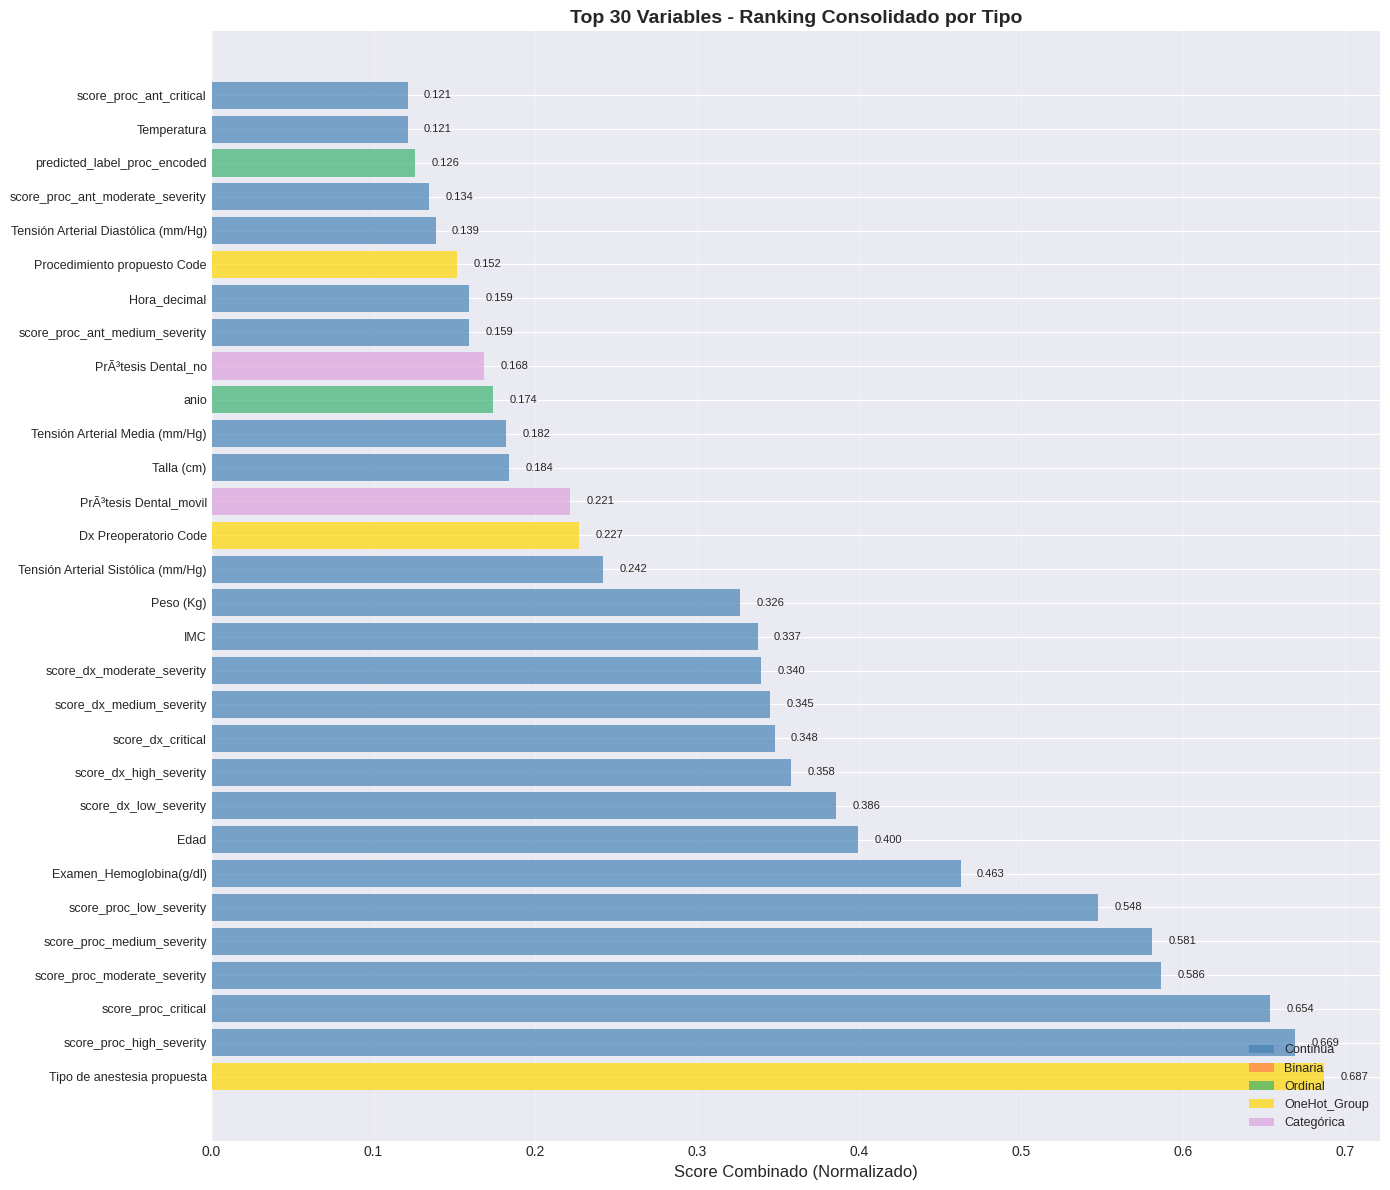

In [48]:
# Visualización del ranking consolidado
top_n = 30
top_vars = consolidated.head(top_n)

# Mapeo de colores por tipo
type_colors = {
    'Continua': 'steelblue',
    'Binaria': 'coral',
    'Ordinal': 'mediumseagreen',
    'OneHot_Group': 'gold',
    'Categórica': 'plum'
}

colors = [type_colors.get(t, 'gray') for t in top_vars['Type']]

fig, ax = plt.subplots(figsize=(14, 12))
bars = ax.barh(range(len(top_vars)), top_vars['Combined_Score'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_vars)))
ax.set_yticklabels(top_vars['Variable'], fontsize=9)
ax.set_xlabel('Score Combinado (Normalizado)', fontsize=12)
ax.set_title(f'Top {top_n} Variables - Ranking Consolidado por Tipo', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Añadir valores
for i, (bar, val) in enumerate(zip(bars, top_vars['Combined_Score'])):
    ax.text(val + 0.01, i, f'{val:.3f}', va='center', ha='left', fontsize=8)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, alpha=0.7, label=tipo) 
                  for tipo, color in type_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

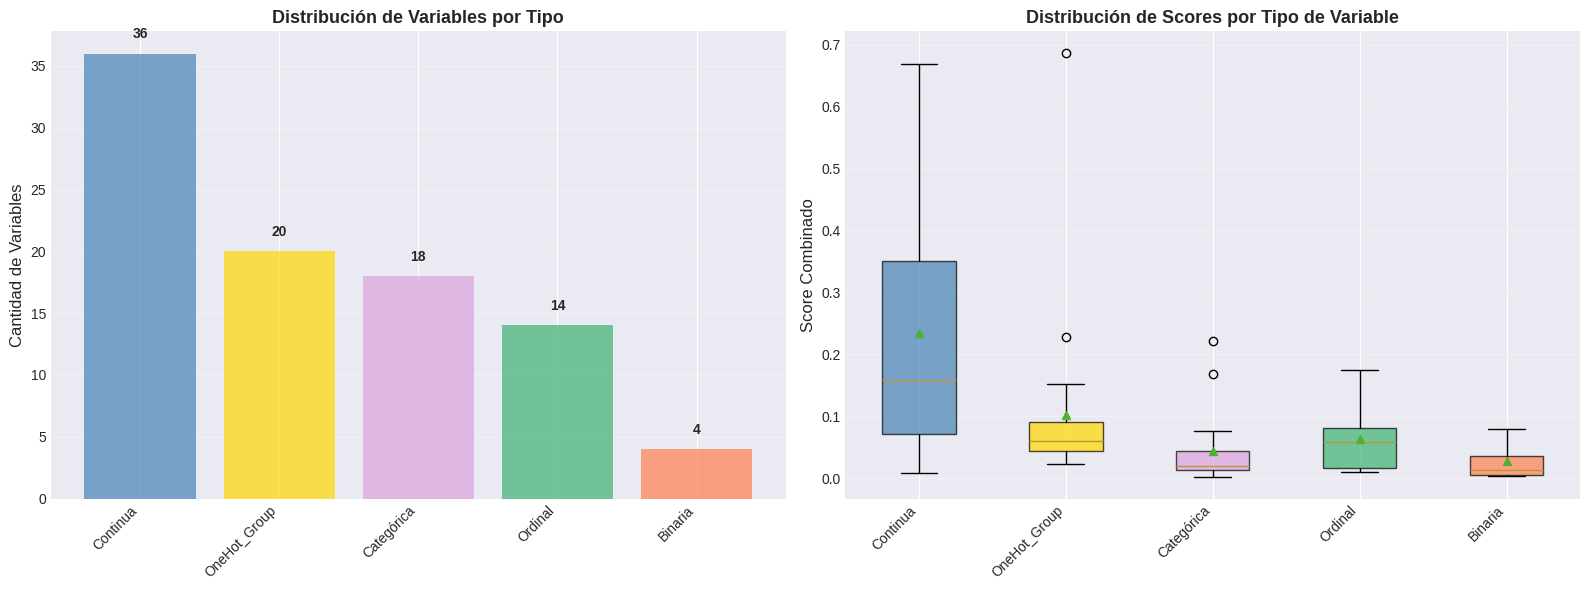

In [49]:
# Distribución de variables por tipo
type_counts = consolidated['Type'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
ax1.bar(range(len(type_counts)), type_counts.values, 
        color=[type_colors.get(t, 'gray') for t in type_counts.index], alpha=0.7)
ax1.set_xticks(range(len(type_counts)))
ax1.set_xticklabels(type_counts.index, rotation=45, ha='right')
ax1.set_ylabel('Cantidad de Variables', fontsize=12)
ax1.set_title('Distribución de Variables por Tipo', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Añadir valores
for i, v in enumerate(type_counts.values):
    ax1.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

# Boxplot de scores por tipo
type_order = type_counts.index.tolist()
data_by_type = [consolidated[consolidated['Type'] == t]['Combined_Score'].dropna() 
                for t in type_order]

bp = ax2.boxplot(data_by_type, labels=type_order, patch_artist=True, showmeans=True)

for patch, tipo in zip(bp['boxes'], type_order):
    patch.set_facecolor(type_colors.get(tipo, 'gray'))
    patch.set_alpha(0.7)

ax2.set_xticklabels(type_order, rotation=45, ha='right')
ax2.set_ylabel('Score Combinado', fontsize=12)
ax2.set_title('Distribución de Scores por Tipo de Variable', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Selección Final de Variables

In [50]:
# Criterios de selección
print("=" * 80)
print("SELECCIÓN FINAL DE VARIABLES")
print("=" * 80)

# Criterio 1: Top por score combinado
top_combined = consolidated.head(50)['Variable'].tolist()
print(f"\n1. Top 50 por Score Combinado: {len(top_combined)} variables")

# Criterio 2: Significancia estadística
significant_vars = consolidated[consolidated['Significant'] == 'Sí']['Variable'].tolist()
print(f"2. Variables estadísticamente significativas (p<0.05): {len(significant_vars)} variables")

# Criterio 3: MI Score alto
mi_threshold = consolidated['MI_Score'].quantile(0.75)
high_mi = consolidated[consolidated['MI_Score'] > mi_threshold]['Variable'].tolist()
print(f"3. Variables con MI Score > percentil 75: {len(high_mi)} variables")

# Criterio 4: RF Importance alto
rf_threshold = consolidated['RF_Importance'].quantile(0.75)
high_rf = consolidated[consolidated['RF_Importance'] > rf_threshold]['Variable'].tolist()
print(f"4. Variables con RF Importance > percentil 75: {len(high_rf)} variables")

# Unión de criterios
selected_vars = list(set(top_combined + significant_vars + high_mi + high_rf))
print(f"\n✓ Total de variables seleccionadas (unión): {len(selected_vars)}")

# Crear DataFrame de seleccionadas
selected_df = consolidated[consolidated['Variable'].isin(selected_vars)].copy()
selected_df['Selected'] = True

print(f"\nDistribución por tipo:")
print(selected_df['Type'].value_counts())

print(f"\nTop 30 variables seleccionadas:")
print(selected_df.head(30)[['Variable', 'Type', 'Metric_Value', 'MI_Score', 
                            'RF_Importance', 'Combined_Score']].to_string(index=False))

SELECCIÓN FINAL DE VARIABLES

1. Top 50 por Score Combinado: 50 variables
2. Variables estadísticamente significativas (p<0.05): 48 variables
3. Variables con MI Score > percentil 75: 19 variables
4. Variables con RF Importance > percentil 75: 19 variables

✓ Total de variables seleccionadas (unión): 61

Distribución por tipo:
Type
Continua        33
OneHot_Group    15
Ordinal          8
Categórica       4
Binaria          1
Name: count, dtype: int64

Top 30 variables seleccionadas:
                           Variable         Type  Metric_Value  MI_Score  RF_Importance  Combined_Score
        Tipo de anestesia propuesta OneHot_Group      0.203856  0.005040       0.038646        0.687298
           score_proc_high_severity     Continua      0.042296  0.049101       0.032588        0.669227
                score_proc_critical     Continua      0.046612  0.049467       0.029603        0.654022
       score_proc_moderate_severity     Continua      0.024703  0.049572       0.025685        0

## 14. Exportación de Resultados

In [ ]:
# Exportar resultados
output_path = '../features/'

# 1. Ranking completo
consolidated.to_csv(f'{output_path}variable_ranking_completo.csv', index=False)
print(f"✓ Exportado: {output_path}variable_ranking_completo.csv")

# 2. Variables seleccionadas
selected_df.to_csv(f'{output_path}variables_seleccionadas.csv', index=False)
print(f"✓ Exportado: {output_path}variables_seleccionadas.csv")

# 3. Resultados por tipo
continuous_df.to_csv(f'{output_path}analisis_continuas.csv', index=False)
binary_df.to_csv(f'{output_path}analisis_binarias.csv', index=False)
ordinal_df.to_csv(f'{output_path}analisis_ordinales.csv', index=False)
onehot_df.to_csv(f'{output_path}analisis_onehot_grupos.csv', index=False)
if len(unclassified_df) > 0:
    unclassified_df.to_csv(f'{output_path}analisis_no_clasificadas.csv', index=False)
print(f"✓ Exportados análisis por tipo")

# 4. Lista simple de features seleccionadas
with open(f'{output_path}selected_features_list.txt', 'w', encoding='utf-8') as f:
    for var in selected_df['Variable'].tolist():
        f.write(f"{var}\n")
print(f"✓ Exportado: {output_path}selected_features_list.txt")

# 5. Resumen
summary = {
    'Total_Variables_Analizadas': len(consolidated),
    'Variables_Continuas': len(continuous_vars),
    'Variables_Binarias': len(binary_vars),
    'Variables_Ordinales': len(ordinal_vars),
    'Grupos_OneHot': len(onehot_groups),
    'Columnas_OneHot': len(all_onehot_cols),
    'Variables_No_Clasificadas': len(unclassified_vars),
    'Variables_Seleccionadas': len(selected_vars),
    'Variables_Significativas': len(significant_vars),
    'Target_0': int(y.value_counts().get(0, 0)),
    'Target_1': int(y.value_counts().get(1, 0)),
    'Total_Muestras': len(df)
}

print("\n" + "=" * 80)
print("RESUMEN FINAL")
print("=" * 80)
for key, value in summary.items():
    print(f"{key.replace('_', ' ')}: {value:,}")

✓ Exportado: ../cache/variable_ranking_completo.csv
✓ Exportado: ../cache/variables_seleccionadas.csv
✓ Exportados análisis por tipo
✓ Exportado: ../cache/selected_features_list.txt
✓ Exportado: ../cache/validation_summary.csv

RESUMEN FINAL
Total Variables Analizadas: 92
Variables Continuas: 36
Variables Binarias: 4
Variables Ordinales: 14
Grupos OneHot: 20
Columnas OneHot: 163
Variables No Clasificadas: 18
Variables Seleccionadas: 61
Variables Significativas: 48
Target 0: 12,390
Target 1: 17,475
Total Muestras: 29,865
